# Verfahrenswahrscheinlichkeit: Wilson-Konfidenzintervalle

Für jede simulierte Binomialstichprobe wird das zugehörige Wilson-Konfidenzintervall dargestellt. Der Punkt auf dem Intervall markiert die beobachtete relative Häufigkeit $h=k/n$.

Intervalle, die den festen Parameterwert $p_0$ nicht enthalten, können farbig markiert werden. Eine Ergebniszahl wird bewusst nicht ausgegeben: Die Grafik bleibt ein **Denkraum**.


## Eingaben

Nur die folgende Zelle muss verändert werden. Die Klasse `Config` bündelt vier Arten von Eingaben:

- mathematische und simulationsbezogene Eingaben,
- Elemente der Grafik,
- Beschriftung,
- Anzeige und Speicherung.

Der feste Seed macht die Simulation transparent reproduzierbar.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import MaxNLocator
import numpy as np


@dataclass(frozen=True)
class Config:
    # Mathematische und simulationsbezogene Eingaben
    n: int = 100
    p0: float = 0.27
    gamma: float = 0.90
    number_of_samples: int = 50
    seed: int = 7

    # Elemente der Grafik
    show_acceptance_limits: bool = True
    color_noncovering: bool = True
    interval_line_width: float = 2.0
    point_size: float = 22.0
    marked_point_size: float = 46.0

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True

    # Ausgabe des Notebooks
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()


## Prüfung, Simulation und mathematische Berechnung

Zunächst werden die Eingaben geprüft. Danach folgen voneinander getrennte Funktionen für Simulation und Wilson-Intervalle. Alle benötigten Größen werden als Argumente übergeben; die mathematischen Funktionen greifen nicht auf globale Zwischenwerte zu.

Die beiden hellgrauen Grenzen gehören zum normalapproximativen Prognoseintervall bei festem $p_0$:

$$
p_0\pm z\sqrt{\frac{p_0(1-p_0)}{n}}.
$$

Ein Punkt liegt genau dann außerhalb dieser Grenzen, wenn das zugehörige Wilson-Intervall den Wert $p_0$ nicht enthält. Das Programm prüft diese Äquivalenz für jede simulierte Stichprobe.


In [2]:
@dataclass(frozen=True)
class Calculation:
    z: float
    hits: np.ndarray
    relative_frequencies: np.ndarray
    wilson_lower: np.ndarray
    wilson_upper: np.ndarray
    contains_p0: np.ndarray
    acceptance_lower: float
    acceptance_upper: float


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not 0.0 <= cfg.p0 <= 1.0:
        raise ValueError("p0 muss zwischen 0 und 1 liegen.")
    if not 0.0 < cfg.gamma < 1.0:
        raise ValueError("gamma muss zwischen 0 und 1 liegen.")
    if (
        not isinstance(cfg.number_of_samples, int)
        or isinstance(cfg.number_of_samples, bool)
        or cfg.number_of_samples <= 0
    ):
        raise ValueError(
            "number_of_samples muss eine positive ganze Zahl sein."
        )
    if not isinstance(cfg.seed, int) or isinstance(cfg.seed, bool) or cfg.seed < 0:
        raise ValueError("seed muss eine nichtnegative ganze Zahl sein.")
    if cfg.interval_line_width <= 0.0:
        raise ValueError("interval_line_width muss positiv sein.")
    if cfg.point_size <= 0.0 or cfg.marked_point_size <= 0.0:
        raise ValueError("Die Punktgrößen müssen positiv sein.")
    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")
    if Path(cfg.output_dir).is_absolute():
        raise ValueError("output_dir muss ein relativer Pfad sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    if cfg.save_figure and not formats:
        raise ValueError("save_formats darf beim Speichern nicht leer sein.")
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def wilson_intervals(
    hits: np.ndarray,
    *,
    n: int,
    z: float,
) -> tuple[np.ndarray, np.ndarray]:
    h = hits / n
    denominator = 1.0 + z**2 / n
    center = (h + z**2 / (2.0 * n)) / denominator
    half_width = (
        z
        * np.sqrt(
            h * (1.0 - h) / n + z**2 / (4.0 * n**2)
        )
        / denominator
    )
    return center - half_width, center + half_width


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    z = NormalDist().inv_cdf((1.0 + cfg.gamma) / 2.0)
    rng = np.random.default_rng(cfg.seed)
    hits = rng.binomial(cfg.n, cfg.p0, size=cfg.number_of_samples)
    relative_frequencies = hits / cfg.n

    wilson_lower, wilson_upper = wilson_intervals(
        hits,
        n=cfg.n,
        z=z,
    )
    contains_p0 = (
        (wilson_lower <= cfg.p0) & (cfg.p0 <= wilson_upper)
    )

    acceptance_half_width = z * np.sqrt(
        cfg.p0 * (1.0 - cfg.p0) / cfg.n
    )
    acceptance_lower = cfg.p0 - acceptance_half_width
    acceptance_upper = cfg.p0 + acceptance_half_width
    inside_acceptance_region = (
        (acceptance_lower <= relative_frequencies)
        & (relative_frequencies <= acceptance_upper)
    )

    if not np.array_equal(contains_p0, inside_acceptance_region):
        raise AssertionError(
            "Prognoseintervall und Wilson-Intervalle stimmen nicht überein."
        )

    return Calculation(
        z=z,
        hits=hits,
        relative_frequencies=relative_frequencies,
        wilson_lower=wilson_lower,
        wilson_upper=wilson_upper,
        contains_p0=contains_p0,
        acceptance_lower=acceptance_lower,
        acceptance_upper=acceptance_upper,
    )


## Grafik

Die Funktion `create_figure()` erzeugt ausschließlich die Grafik. Titel und Untertitel können unabhängig voneinander ein- und ausgeblendet werden; der Untertitel enthält nur Eingaben.

Die senkrechte dunkle Linie markiert $p_0$. Die beiden hellgrauen Linien zeigen -- falls eingeschaltet -- die Grenzen des zugehörigen Prognoseintervalls für $H$. Die Farbe hebt Nichtüberdeckungen hervor, ohne sie zu zählen.


In [3]:
def interval_axis_limits(
    calculation: Calculation,
    *,
    p0: float,
) -> tuple[float, float]:
    data_lower = min(float(np.min(calculation.wilson_lower)), p0)
    data_upper = max(float(np.max(calculation.wilson_upper)), p0)
    padding = max(0.005, 0.015 * (data_upper - data_lower))
    lower = max(0.0, np.floor((data_lower - padding) * 10.0) / 10.0)
    upper = min(1.0, np.ceil((data_upper + padding) * 10.0) / 10.0)

    if upper - lower < 0.2:
        center = (lower + upper) / 2.0
        lower = max(0.0, center - 0.1)
        upper = min(1.0, center + 0.1)

    return float(lower), float(upper)


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[Figure, Axes]:
    fig, ax = plt.subplots(figsize=(7.2, 7.2))
    sample_number = np.arange(1, cfg.number_of_samples + 1)

    ax.hlines(
        sample_number,
        calculation.wilson_lower,
        calculation.wilson_upper,
        color="0.38",
        linewidth=cfg.interval_line_width,
        zorder=1,
    )

    if cfg.show_acceptance_limits:
        ax.axvline(
            calculation.acceptance_lower,
            color="0.72",
            linestyle="--",
            linewidth=2.0,
            zorder=0,
        )
        ax.axvline(
            calculation.acceptance_upper,
            color="0.72",
            linestyle="--",
            linewidth=2.0,
            zorder=0,
        )

    ax.axvline(
        cfg.p0,
        color="0.35",
        linestyle="--",
        linewidth=2.0,
        zorder=0,
    )

    if cfg.color_noncovering:
        ordinary = calculation.contains_p0
    else:
        ordinary = np.ones_like(calculation.contains_p0, dtype=bool)

    ax.scatter(
        calculation.relative_frequencies[ordinary],
        sample_number[ordinary],
        s=cfg.point_size,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=3,
    )

    if cfg.color_noncovering:
        ax.scatter(
            calculation.relative_frequencies[~calculation.contains_p0],
            sample_number[~calculation.contains_p0],
            s=cfg.marked_point_size,
            facecolors="red",
            edgecolors="black",
            linewidths=1.3,
            zorder=4,
        )

    x_limits = interval_axis_limits(calculation, p0=cfg.p0)
    ax.set(
        xlim=x_limits,
        ylim=(0.0, cfg.number_of_samples + 1),
        xlabel=r"$p$",
        ylabel="Stichprobe",
    )
    ax.set_xticks(
        np.arange(x_limits[0], x_limits[1] + 0.05, 0.1)
    )
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.set_box_aspect(1.0)

    for spine in ax.spines.values():
        spine.set_color("0.72")
    ax.tick_params(labelsize=11)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)

    title = r"Verfahrenswahrscheinlichkeit: Wilson-Konfidenzintervalle"
    subtitle = (
        rf"$n={cfg.n},\quad p_0={cfg.p0:.2f},\quad "
        rf"\gamma={cfg.gamma:.2f}$; "
        f"{cfg.number_of_samples} Stichproben; Seed = {cfg.seed}"
    )

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=16, pad=32)
        ax.text(
            0.5,
            1.025,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=11,
            color="0.35",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=16, pad=13)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=11, color="0.35", pad=13)

    fig.tight_layout()
    return fig, ax


## Ausgabe

Berechnung, Erzeugung der Grafik sowie Anzeige und Speicherung bleiben getrennt. Die Grafik kann unabhängig voneinander angezeigt und gespeichert werden.

Ist `save_figure = True`, wird der relative Unterordner `fig/` bei Bedarf automatisch angelegt. PNG- und PDF-Dateien werden dort gesammelt; das Verzeichnis des Notebooks bleibt frei von einzelnen Grafikdateien.

Für die Standardeinstellungen entstehen

- `Verfahrenswahrscheinlichkeit-Wilson-Intervalle-n100-p027-gamma090-stichproben50-seed7.png`,
- `Verfahrenswahrscheinlichkeit-Wilson-Intervalle-n100-p027-gamma090-stichproben50-seed7.pdf`.

Die letzte Zelle zeigt ausschließlich die Grafik. Sie gibt weder die Zahl der markierten Intervalle noch eine daraus abgeleitete Verfahrenswahrscheinlichkeit aus.


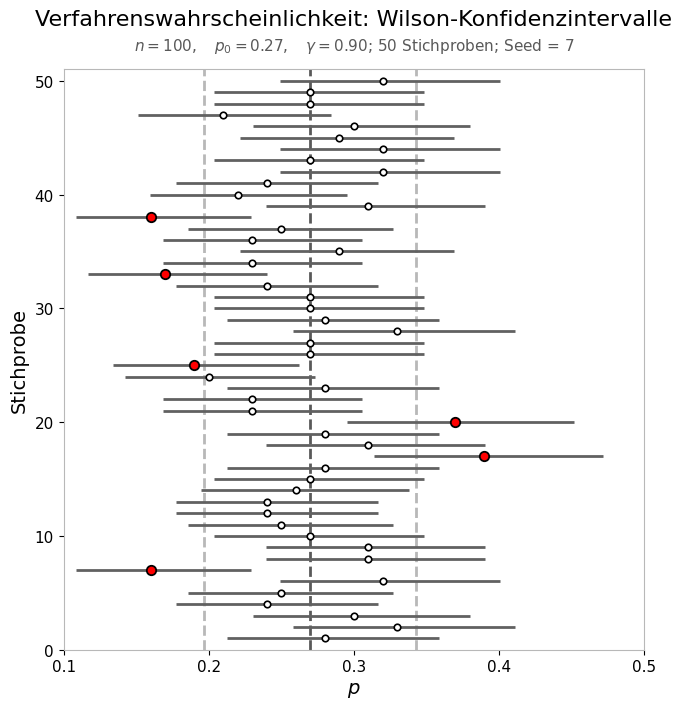

In [4]:
def probability_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    integer, separator, decimals = text.partition(".")
    decimals = decimals.ljust(2, "0") if separator else "00"
    return f"{integer}{decimals}".replace("-", "m")


def figure_stem(cfg: Config) -> str:
    p0 = probability_token(cfg.p0)
    gamma = probability_token(cfg.gamma)
    return (
        f"Verfahrenswahrscheinlichkeit-Wilson-Intervalle-"
        f"n{cfg.n}-p{p0}-gamma{gamma}-"
        f"stichproben{cfg.number_of_samples}-seed{cfg.seed}"
    )


def save_figure(
    fig: Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)
